In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import mpl_scatter_density
from astropy.visualization.mpl_normalize import ImageNormalize

import healpy as hp
from scipy import stats
from IPython.display import Image

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

plt.rcParams['image.cmap'] = 'seismic'

In [3]:
error_of_the_mean = lambda x: np.std(x)/np.sqrt(len(x))

def binned_mean(x, y, bin_edges=None, weights=None, minsize=30, nbins=30, percentiles=[0.5, 99.5]):
    if bin_edges is None:
        vmin, vmax = np.percentile(x, percentiles)
        bin_edges = np.linspace(vmin, vmax, nbins)
    if weights is None:
        weights = np.ones(len(x))
    bin_mean = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_mean[index]=np.nan
        else:
            bin_mean[index] = np.sum(y[mask]*weights[mask])/np.sum(weights[mask])    
    bin_error, _, _ = stats.binned_statistic(x, y, statistic=error_of_the_mean, bins=bin_edges)
    bin_error[np.isnan(bin_mean)] = np.nan
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    
    return bin_center, bin_edges, bin_mean, bin_error

In [4]:
data_dir = '/Volumes/Samsung T5/tmp/dr9_tests'
target_class = 'QSO'

In [5]:
xnames = ['stardens', 'EBV', 'psfdepth_gmag', 'psfdepth_rmag', 'psfdepth_zmag', 'psfdepth_w1mag', 'psfdepth_w2mag', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z']
xlabels = ['GAIA stellar density [deg$^{-2}$]', 'E(B-V)', 'g-band PSF depth [mag]', 'r-band PSF depth [mag]', 'z-band PSF depth [mag]', 'W1-band PSF depth [mag]', 'W2-band PSF depth [mag]', 'g-band PSF size [arcsec]', 'r-band PSF size [arcsec]', 'z-band PSF size [arcsec]']
xlabels_ebv = ['GAIA stellar density [deg$^{-2}$]', 'E(B-V)', 'g-band PSF depth - 3.214*E(B-V) [mag]', 'r-band PSF depth - 2.165*E(B-V) [mag]', 'z-band PSF depth - 1.211*E(B-V) [mag]', 'W1-band PSF depth - 0.184*E(B-V) [mag]', 'W2-band PSF depth - 0.113*E(B-V) [mag]', 'g-band PSF size [arcsec]', 'r-band PSF size [arcsec]', 'z-band PSF size [arcsec]']

bin_params = {}
bin_params['stardens'], bin_params['stardens_nbins'] = np.array([200, 4000]), 30
bin_params['stardens_log'], bin_params['stardens_log_nbins'] = np.array([2.3, 3.6]), 30
bin_params['EBV'], bin_params['EBV_nbins'] = np.array([0., 0.15]), 30
bin_params['galdepth_gmag'], bin_params['galdepth_gmag_nbins'] = np.array([23.75, 25.0]), 50
bin_params['galdepth_rmag'], bin_params['galdepth_rmag_nbins'] = np.array([23.1, 24.8]), 50
bin_params['galdepth_zmag'], bin_params['galdepth_zmag_nbins'] = np.array([22.5, 23.65]), 50
bin_params['psfdepth_gmag'], bin_params['psfdepth_gmag_nbins'] = np.array([23.75+0.2, 25.0+0.35]), 50
bin_params['psfdepth_rmag'], bin_params['psfdepth_rmag_nbins'] = np.array([23.1+0.2, 24.8+0.4]), 50
bin_params['psfdepth_zmag'], bin_params['psfdepth_zmag_nbins'] = np.array([22.5+0.3, 23.65+0.4]), 50
bin_params['psfdepth_w1mag'], bin_params['psfdepth_w1mag_nbins'] = np.array([21.2, 22.2]), 50
bin_params['psfdepth_w2mag'], bin_params['psfdepth_w2mag_nbins'] = np.array([20.5, 21.8]), 50
bin_params['PSFSIZE_G'], bin_params['PSFSIZE_G_nbins'] = np.array([1.1, 2.5]), 30
bin_params['PSFSIZE_R'], bin_params['PSFSIZE_R_nbins'] = np.array([1.0, 2.3]), 30
bin_params['PSFSIZE_Z'], bin_params['PSFSIZE_Z_nbins'] = np.array([0.9, 1.9]), 30
bin_params['galdepth_gmag_ebv'], bin_params['galdepth_gmag_ebv_nbins'] = bin_params['galdepth_gmag'] - 0.1, 50
bin_params['galdepth_rmag_ebv'], bin_params['galdepth_rmag_ebv_nbins'] = bin_params['galdepth_rmag'] - 0.1, 50
bin_params['galdepth_zmag_ebv'], bin_params['galdepth_zmag_ebv_nbins'] = bin_params['galdepth_zmag'] - 0.05, 50
bin_params['psfdepth_w1mag_ebv'], bin_params['psfdepth_w1mag_ebv_nbins'] = bin_params['psfdepth_w1mag'], 50
bin_params['psfdepth_w2mag_ebv'], bin_params['psfdepth_w2mag_ebv_nbins'] = bin_params['psfdepth_w2mag'], 50
bin_params['psfdepth_gmag_ebv'], bin_params['psfdepth_gmag_ebv_nbins'] = bin_params['psfdepth_gmag'] - 0.1, 50
bin_params['psfdepth_rmag_ebv'], bin_params['psfdepth_rmag_ebv_nbins'] = bin_params['psfdepth_rmag'] - 0.1, 50
bin_params['psfdepth_zmag_ebv'], bin_params['psfdepth_zmag_ebv_nbins'] = bin_params['psfdepth_zmag'] - 0.05, 50
bin_params['psfdepth_w1mag_ebv'], bin_params['psfdepth_w1mag_ebv_nbins'] = bin_params['psfdepth_w1mag'], 50
bin_params['psfdepth_w2mag_ebv'], bin_params['psfdepth_w2mag_ebv_nbins'] = bin_params['psfdepth_w2mag'], 50

-------
## NSIDE=64

In [6]:
nside = 64
min_pix_frac = 0.2 # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

Healpix size = 0.83929 sq deg


In [7]:
field = 'north'
density_map = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))
maps = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}.fits'.format(field, nside)))
print(len(density_map))
print(len(maps))

density_map = density_map[['hp_idx', 'count']]
maps = join(density_map, maps, keys='hp_idx', join_type='inner')
print(len(maps))

maps['density'] = maps['count']/(maps['pix_frac']*pix_area)
area = np.sum(maps['pix_frac'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['pix_frac']>min_pix_frac
maps = maps[mask]

# Load stellar density map
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
maps['stardens'] = stardens[maps['hp_idx']]
maps['stardens_log'] = np.log10(maps['stardens'])

maps_north = maps.copy()

#####################################################################

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps['hp_idx']] = maps['density']
hp_mask[maps['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

mean_density = np.sum(maps['density']*maps['pix_frac'])/np.sum(maps['pix_frac'])
print('Average density: {:.1f} (per square degree)'.format(mean_density))

# # 68% confidence interval from Poisson uncertainty
# plt.figure(figsize=(7, 5.8))
# plt.hist(density[hp_mask], range=(1000, 3500), bins=100, alpha=0.5, label='Density variation')
# # density_low = mean_density*(1-np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # density_high = mean_density*(1+np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # plt.axvspan(density_low, density_high, alpha=0.4, color='grey', label='Poisson uncertainty (68%)')
# plt.axvline(mean_density, label='Average density', color='C3')
# plt.xlabel('density (per sq deg)')
# plt.xlim(1000, 3500)
# plt.legend()
# plt.show()

# print('Density (per square degree):')
# plt.figure(figsize=(25, 5))
# hp.cartview(mplot, min=1000, max=4000, rot=(180, 0, 0), fig=1, latra=[30, 85], lonra=[-120, 140], xsize=4000, ysize=4000)

6281
6283
6281
Area = 4670.3 sq deg
Average density: 297.0 (per square degree)


In [8]:
field = 'south'
density_map = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))
maps = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}.fits'.format(field, nside)))
print(len(density_map))
print(len(maps))

density_map = density_map[['hp_idx', 'count']]
maps = join(density_map, maps, keys='hp_idx', join_type='inner')
print(len(maps))

maps['density'] = maps['count']/(maps['pix_frac']*pix_area)
area = np.sum(maps['pix_frac'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['pix_frac']>min_pix_frac
maps = maps[mask]

# Load stellar density map
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
maps['stardens'] = stardens[maps['hp_idx']]
maps['stardens_log'] = np.log10(maps['stardens'])

maps_south = maps.copy()

#####################################################################

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps['hp_idx']] = maps['density']
hp_mask[maps['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

mean_density = np.sum(maps['density']*maps['pix_frac'])/np.sum(maps['pix_frac'])
print('Average density: {:.1f} (per square degree)'.format(mean_density))

# # 68% confidence interval from Poisson uncertainty
# plt.figure(figsize=(7, 5.8))
# plt.hist(density[hp_mask], range=(1500, 4500), bins=100, alpha=0.5, label='Density variation')
# # density_low = mean_density*(1-np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # density_high = mean_density*(1+np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # plt.axvspan(density_low, density_high, alpha=0.4, color='grey', label='Poisson uncertainty (68%)')
# plt.axvline(mean_density, label='Average density', color='C3')
# plt.xlabel('density (per sq deg)')
# plt.xlim(1500, 4500)
# plt.legend()
# plt.show()

# print('Density (per square degree):')
# plt.figure(figsize=(25, 5))
# hp.cartview(mplot, min=1500, max=4500, rot=(110, 0, 0), fig=1, latra=[-32, 35], xsize=4000, ysize=4000)

11069
11182
11069
Area = 6482.4 sq deg
Average density: 279.5 (per square degree)


/Users/rongpu/miniconda3/lib/python3.7/site-packages/healpy/projaxes.py:211: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  **kwds


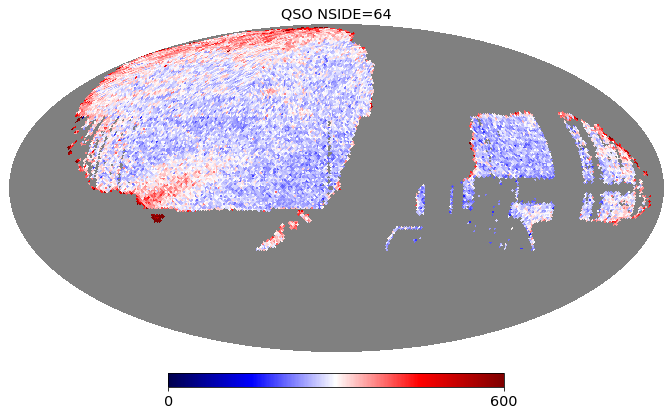

In [9]:
mask = ~np.in1d(maps_north['hp_idx'], maps_south['hp_idx'])
maps_combined = vstack([maps_north[mask], maps_south])
maps_combined.sort('hp_idx')

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps_combined['hp_idx']] = maps_combined['density']
hp_mask[maps_combined['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

plt.figure(figsize=(9.7, 6))
hp.mollview(mplot, min=0, max=600, rot=(120, 0, 0), fig=1, xsize=8000, title='{} NSIDE={}'.format(target_class, nside))
plt.savefig('plots/{}_{}.png'.format(target_class, nside), dpi=200)
plt.show()

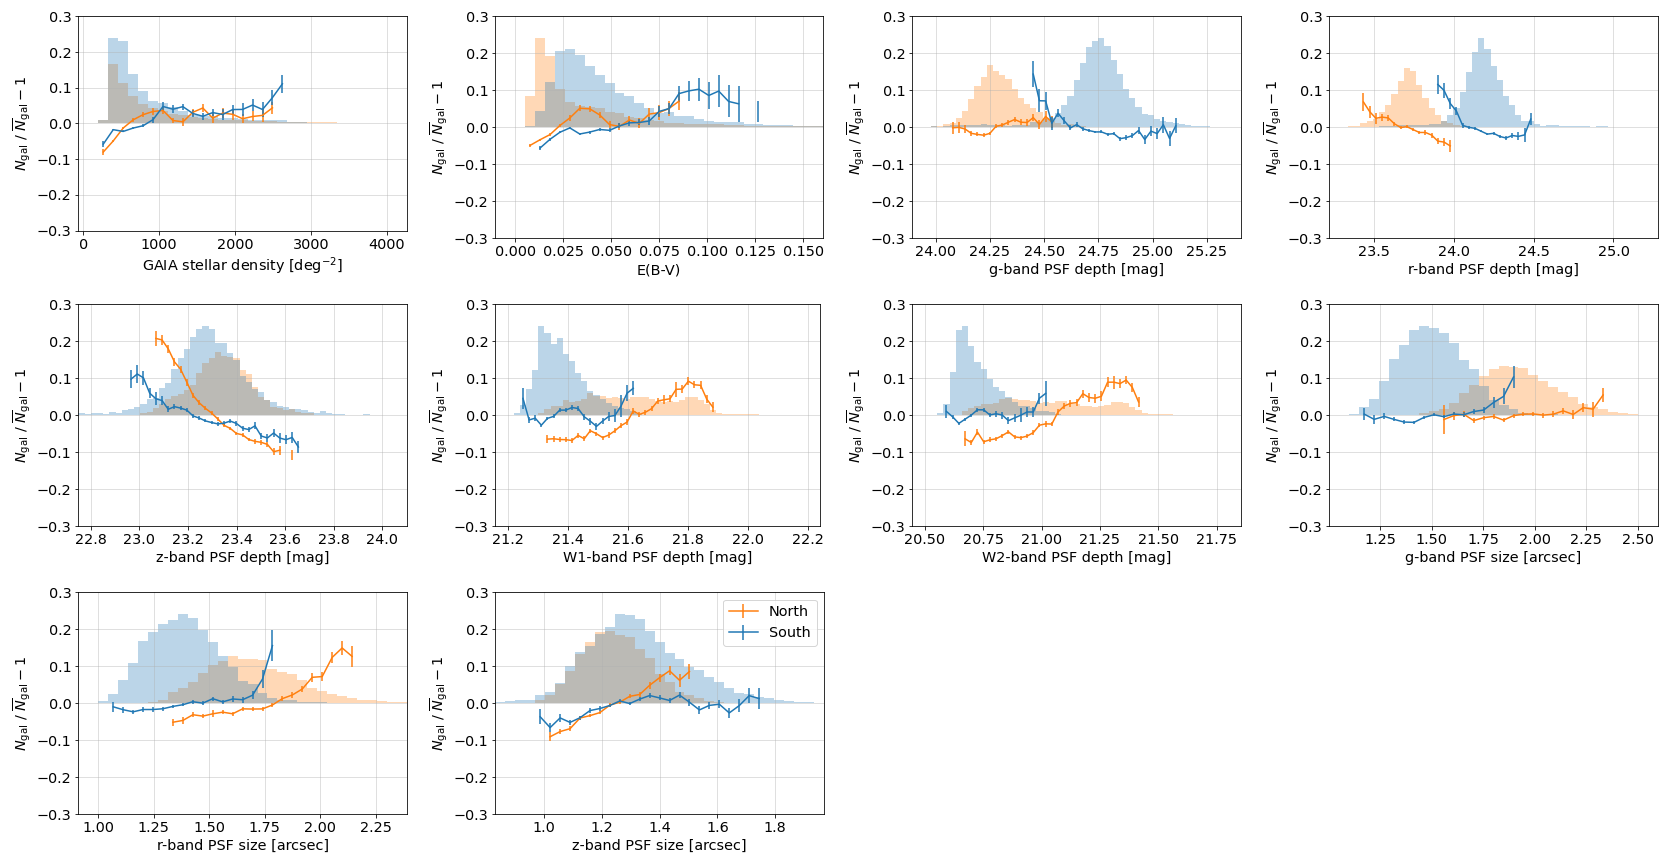

In [10]:
var_range = 0.3
minsize = 50

for index, xname in enumerate(xnames):
    
    bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])
        
    bin_width = bin_edges[1]-bin_edges[0]
    histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
    xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

    # normalize the histograms to the histogram of the full sample
    bincount_max = np.maximum(np.histogram(maps_north[xname], bins=histbin_edge)[0].max(), 
                              np.histogram(maps_south[xname], bins=histbin_edge)[0].max())

    fig, ax = plt.subplots(figsize=(5.8, 4))

    maps_mask = np.ones(len(maps_north), dtype=bool)
    mean_density = np.sum(maps_north['density']*maps_north['pix_frac'])/np.sum(maps_north['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_north[xname][maps_mask], maps_north['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_north['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_north[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='North', color='C1')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C1')

    maps_mask = np.ones(len(maps_south), dtype=bool)
    mean_density = np.sum(maps_south['density']*maps_south['pix_frac'])/np.sum(maps_south['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_south[xname][maps_mask], maps_south['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_south['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_south[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='South', color='C0')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C0')

    ax.grid(alpha=0.5)
    ax.set_xlabel(xlabels[index])
    ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
    ax.axis([xmin, xmax, -var_range, var_range])
    if index==len(xnames)-1:
        plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
    plt.close()

os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 4x plots/tmp_systematics_{}_{}.png'.format(target_class, len(xnames), target_class, nside))
Image(filename='plots/tmp_systematics_{}_{}.png'.format(target_class, nside))

__Use EBV-corrected depths__

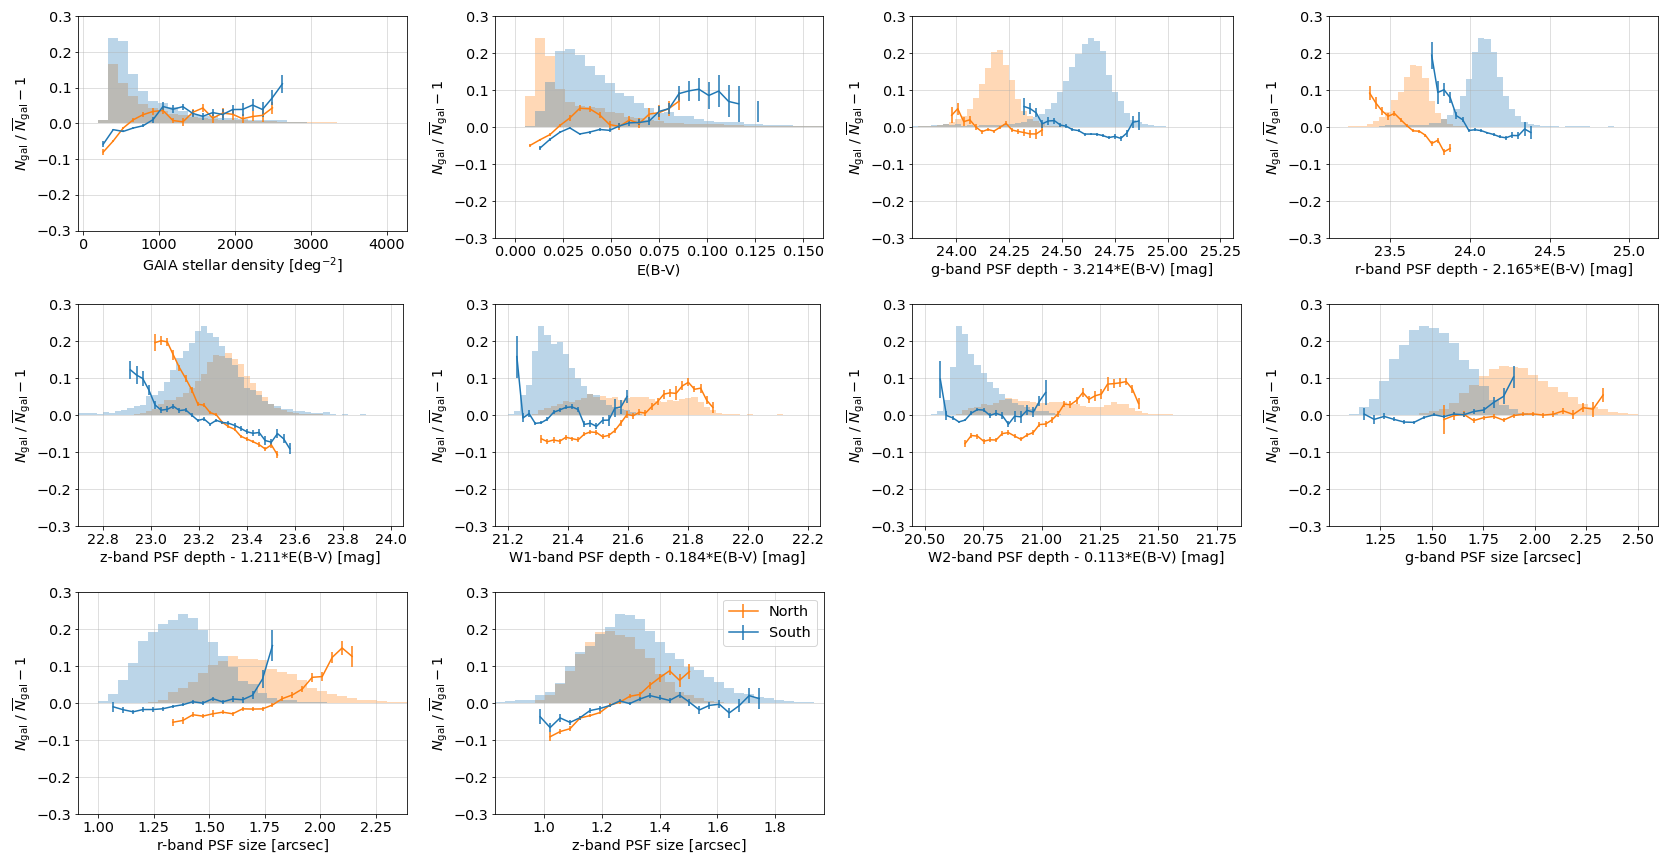

In [11]:
var_range = 0.3
minsize = 50

for index, xname in enumerate(xnames):
    
    if 'depth' in xname:
        xname += '_ebv'
    bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])
        
    bin_width = bin_edges[1]-bin_edges[0]
    histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
    xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

    # normalize the histograms to the histogram of the full sample
    bincount_max = np.maximum(np.histogram(maps_north[xname], bins=histbin_edge)[0].max(), 
                              np.histogram(maps_south[xname], bins=histbin_edge)[0].max())

    fig, ax = plt.subplots(figsize=(5.8, 4))

    maps_mask = np.ones(len(maps_north), dtype=bool)
    mean_density = np.sum(maps_north['density']*maps_north['pix_frac'])/np.sum(maps_north['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_north[xname][maps_mask], maps_north['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_north['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_north[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='North', color='C1')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C1')

    maps_mask = np.ones(len(maps_south), dtype=bool)
    mean_density = np.sum(maps_south['density']*maps_south['pix_frac'])/np.sum(maps_south['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_south[xname][maps_mask], maps_south['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_south['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_south[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='South', color='C0')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C0')

    ax.grid(alpha=0.5)
    ax.set_xlabel(xlabels_ebv[index])
    ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
    ax.axis([xmin, xmax, -var_range, var_range])
    if index==len(xnames)-1:
        plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
    plt.close()

os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 4x plots/tmp_systematics_{}_{}_ebv_corr.png'.format(target_class, len(xnames), target_class, nside))
Image(filename='plots/tmp_systematics_{}_{}_ebv_corr.png'.format(target_class, nside))

-------
## NSIDE=128

In [12]:
nside = 128
min_pix_frac = 0.2 # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

Healpix size = 0.20982 sq deg


In [13]:
field = 'north'
density_map = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))
maps = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}.fits'.format(field, nside)))
print(len(density_map))
print(len(maps))

density_map = density_map[['hp_idx', 'count']]
maps = join(density_map, maps, keys='hp_idx', join_type='inner')
print(len(maps))

maps['density'] = maps['count']/(maps['pix_frac']*pix_area)
area = np.sum(maps['pix_frac'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['pix_frac']>min_pix_frac
maps = maps[mask]

# Load stellar density map
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
maps['stardens'] = stardens[maps['hp_idx']]
maps['stardens_log'] = np.log10(maps['stardens'])

maps_north = maps.copy()

#####################################################################

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps['hp_idx']] = maps['density']
hp_mask[maps['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

mean_density = np.sum(maps['density']*maps['pix_frac'])/np.sum(maps['pix_frac'])
print('Average density: {:.1f} (per square degree)'.format(mean_density))

# # 68% confidence interval from Poisson uncertainty
# plt.figure(figsize=(7, 5.8))
# plt.hist(density[hp_mask], range=(1000, 3500), bins=100, alpha=0.5, label='Density variation')
# # density_low = mean_density*(1-np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # density_high = mean_density*(1+np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # plt.axvspan(density_low, density_high, alpha=0.4, color='grey', label='Poisson uncertainty (68%)')
# plt.axvline(mean_density, label='Average density', color='C3')
# plt.xlabel('density (per sq deg)')
# plt.xlim(1000, 3500)
# plt.legend()
# plt.show()

# print('Density (per square degree):')
# plt.figure(figsize=(25, 5))
# hp.cartview(mplot, min=1000, max=4000, rot=(180, 0, 0), fig=1, latra=[30, 85], lonra=[-120, 140], xsize=4000, ysize=4000)

24685
24791
24685
Area = 4670.0 sq deg
Average density: 297.0 (per square degree)


In [14]:
field = 'south'
density_map = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))
maps = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}.fits'.format(field, nside)))
print(len(density_map))
print(len(maps))

density_map = density_map[['hp_idx', 'count']]
maps = join(density_map, maps, keys='hp_idx', join_type='inner')
print(len(maps))

maps['density'] = maps['count']/(maps['pix_frac']*pix_area)
area = np.sum(maps['pix_frac'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['pix_frac']>min_pix_frac
maps = maps[mask]

# Load stellar density map
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
maps['stardens'] = stardens[maps['hp_idx']]
maps['stardens_log'] = np.log10(maps['stardens'])

maps_south = maps.copy()

#####################################################################

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps['hp_idx']] = maps['density']
hp_mask[maps['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

mean_density = np.sum(maps['density']*maps['pix_frac'])/np.sum(maps['pix_frac'])
print('Average density: {:.1f} (per square degree)'.format(mean_density))

# # 68% confidence interval from Poisson uncertainty
# plt.figure(figsize=(7, 5.8))
# plt.hist(density[hp_mask], range=(1500, 4500), bins=100, alpha=0.5, label='Density variation')
# # density_low = mean_density*(1-np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # density_high = mean_density*(1+np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # plt.axvspan(density_low, density_high, alpha=0.4, color='grey', label='Poisson uncertainty (68%)')
# plt.axvline(mean_density, label='Average density', color='C3')
# plt.xlabel('density (per sq deg)')
# plt.xlim(1500, 4500)
# plt.legend()
# plt.show()

# print('Density (per square degree):')
# plt.figure(figsize=(25, 5))
# hp.cartview(mplot, min=1500, max=4500, rot=(110, 0, 0), fig=1, latra=[-32, 35], xsize=4000, ysize=4000)

40668
41314
40658
Area = 6480.9 sq deg
Average density: 279.7 (per square degree)


/Users/rongpu/miniconda3/lib/python3.7/site-packages/healpy/projaxes.py:211: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  **kwds


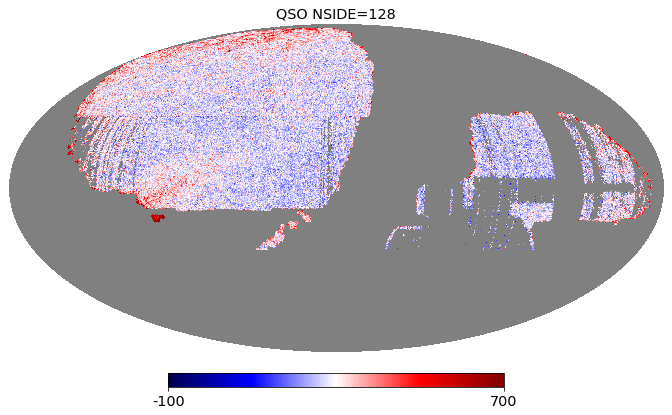

In [15]:
mask = ~np.in1d(maps_north['hp_idx'], maps_south['hp_idx'])
maps_combined = vstack([maps_north[mask], maps_south])
maps_combined.sort('hp_idx')

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps_combined['hp_idx']] = maps_combined['density']
hp_mask[maps_combined['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

plt.figure(figsize=(9.7, 6))
hp.mollview(mplot, min=-100, max=700, rot=(120, 0, 0), fig=1, xsize=8000, title='{} NSIDE={}'.format(target_class, nside))
plt.savefig('plots/{}_{}.png'.format(target_class, nside), dpi=200)
plt.show()

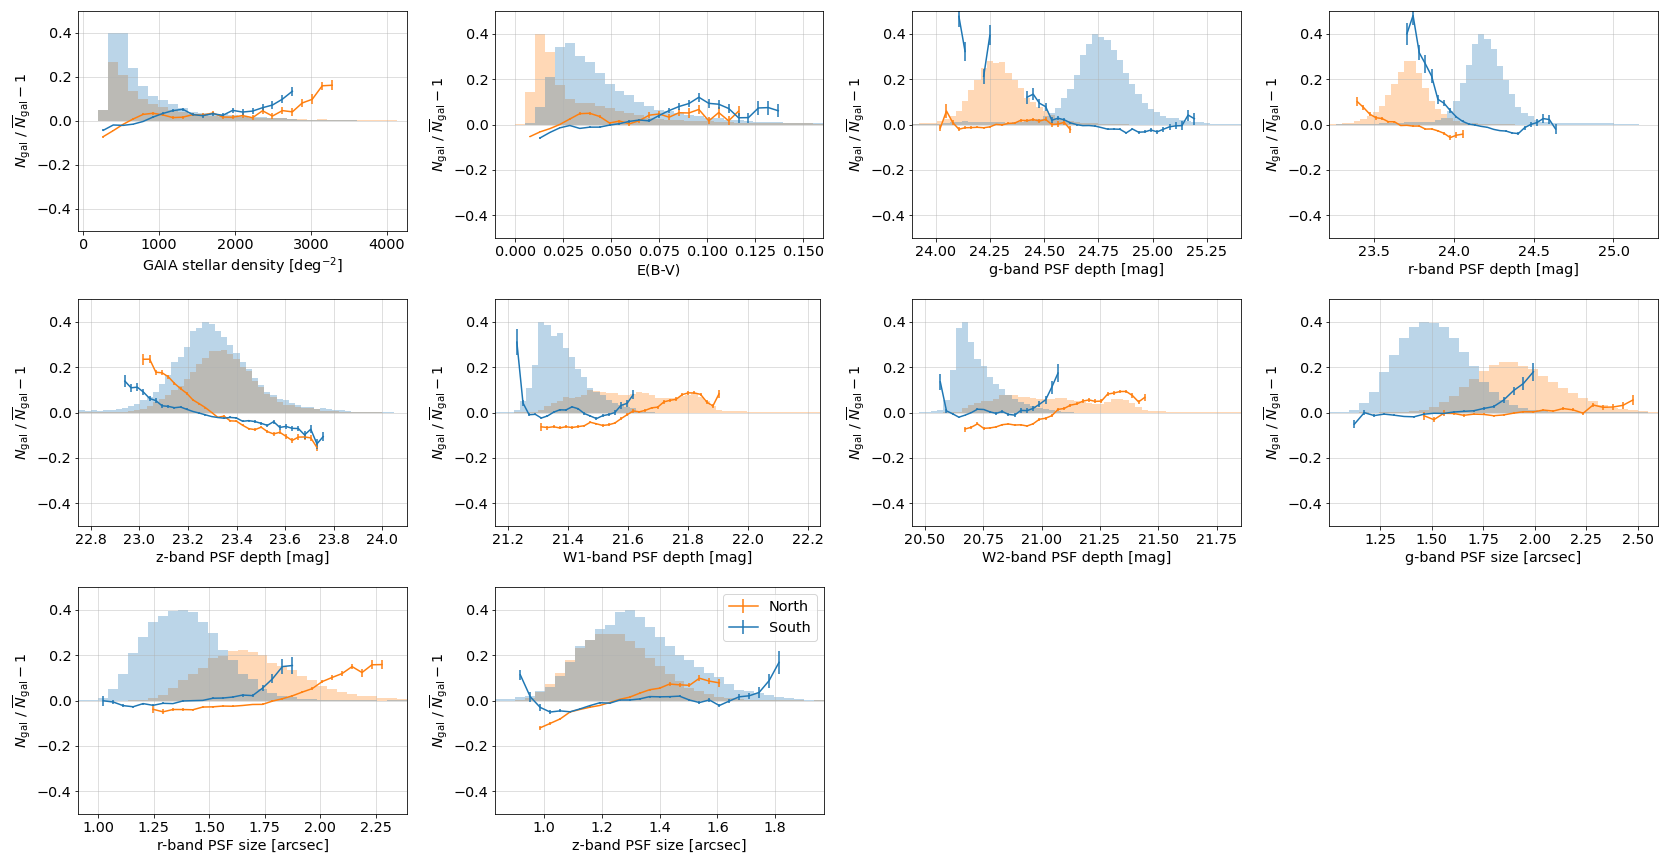

In [16]:
var_range = 0.5
minsize = 100

for index, xname in enumerate(xnames):
    
    bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])
        
    bin_width = bin_edges[1]-bin_edges[0]
    histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
    xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

    # normalize the histograms to the histogram of the full sample
    bincount_max = np.maximum(np.histogram(maps_north[xname], bins=histbin_edge)[0].max(), 
                              np.histogram(maps_south[xname], bins=histbin_edge)[0].max())

    fig, ax = plt.subplots(figsize=(5.8, 4))

    maps_mask = np.ones(len(maps_north), dtype=bool)
    mean_density = np.sum(maps_north['density']*maps_north['pix_frac'])/np.sum(maps_north['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_north[xname][maps_mask], maps_north['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_north['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_north[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='North', color='C1')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C1')

    maps_mask = np.ones(len(maps_south), dtype=bool)
    mean_density = np.sum(maps_south['density']*maps_south['pix_frac'])/np.sum(maps_south['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_south[xname][maps_mask], maps_south['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_south['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_south[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='South', color='C0')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C0')

    ax.grid(alpha=0.5)
    ax.set_xlabel(xlabels[index])
    ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
    ax.axis([xmin, xmax, -var_range, var_range])
    if index==len(xnames)-1:
        plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
    plt.close()

os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 4x plots/tmp_systematics_{}_{}.png'.format(target_class, len(xnames), target_class, nside))
Image(filename='plots/tmp_systematics_{}_{}.png'.format(target_class, nside))

__Use EBV-corrected depths__

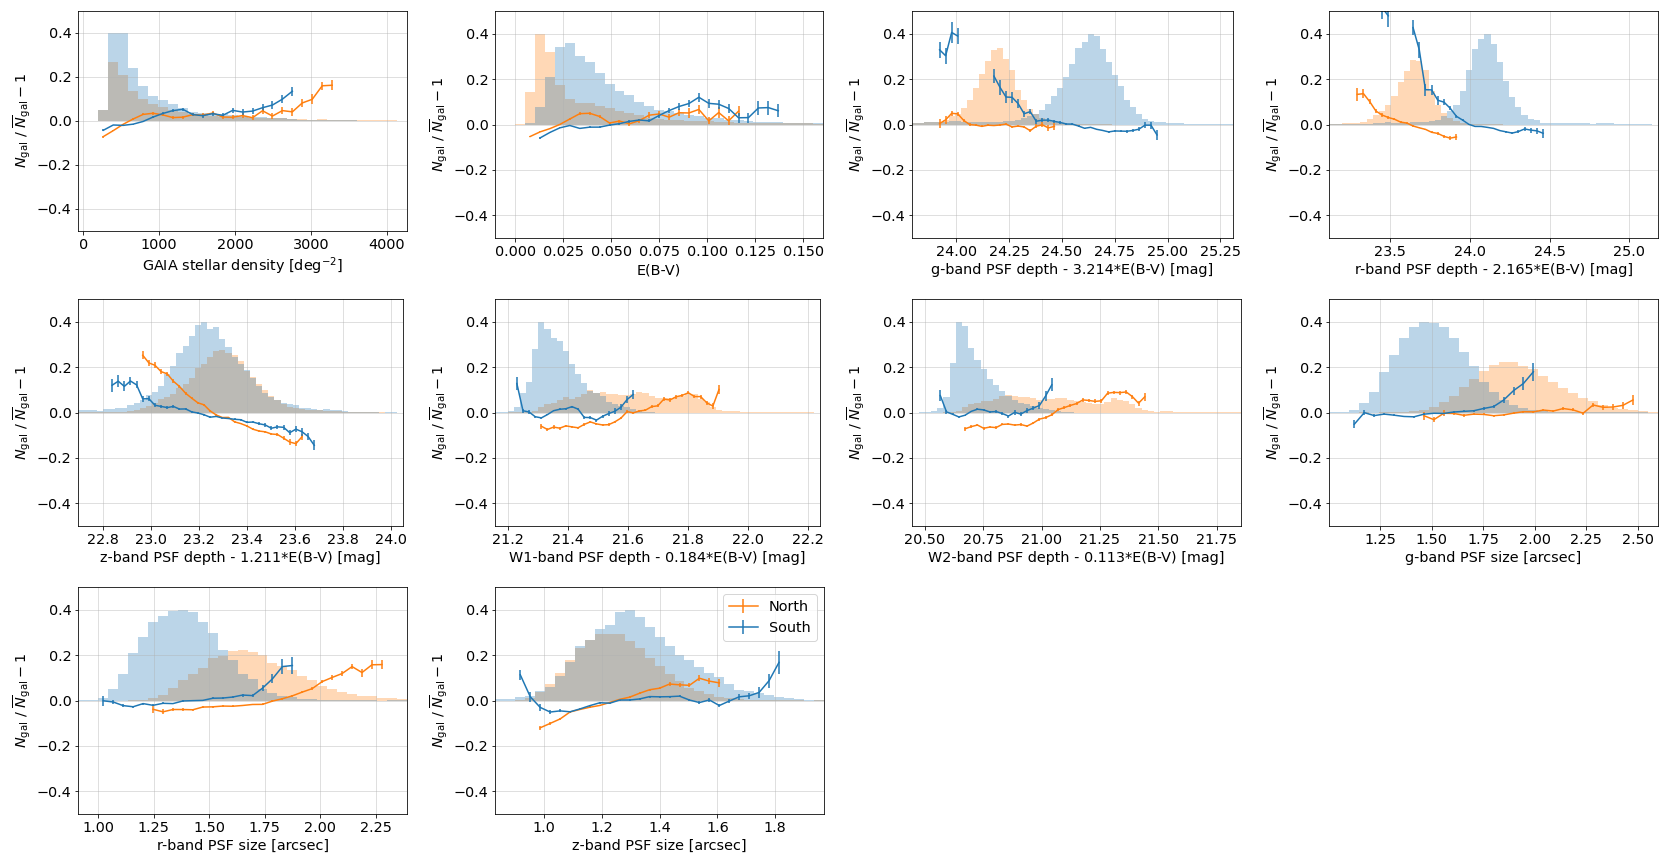

In [17]:
var_range = 0.5
minsize = 100

for index, xname in enumerate(xnames):
    
    if 'depth' in xname:
        xname += '_ebv'
    bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])
        
    bin_width = bin_edges[1]-bin_edges[0]
    histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
    xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

    # normalize the histograms to the histogram of the full sample
    bincount_max = np.maximum(np.histogram(maps_north[xname], bins=histbin_edge)[0].max(), 
                              np.histogram(maps_south[xname], bins=histbin_edge)[0].max())

    fig, ax = plt.subplots(figsize=(5.8, 4))

    maps_mask = np.ones(len(maps_north), dtype=bool)
    mean_density = np.sum(maps_north['density']*maps_north['pix_frac'])/np.sum(maps_north['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_north[xname][maps_mask], maps_north['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_north['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_north[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='North', color='C1')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C1')

    maps_mask = np.ones(len(maps_south), dtype=bool)
    mean_density = np.sum(maps_south['density']*maps_south['pix_frac'])/np.sum(maps_south['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_south[xname][maps_mask], maps_south['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_south['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_south[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='South', color='C0')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C0')

    ax.grid(alpha=0.5)
    ax.set_xlabel(xlabels_ebv[index])
    ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
    ax.axis([xmin, xmax, -var_range, var_range])
    if index==len(xnames)-1:
        plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
    plt.close()

os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 4x plots/tmp_systematics_{}_{}_ebv_corr.png'.format(target_class, len(xnames), target_class, nside))
Image(filename='plots/tmp_systematics_{}_{}_ebv_corr.png'.format(target_class, nside))

-------
## NSIDE=256

In [18]:
nside = 256
min_pix_frac = 0.2 # minimum fraction of pixel area to be used

npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

Healpix size = 0.05246 sq deg


In [19]:
field = 'north'
density_map = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))
maps = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}.fits'.format(field, nside)))
print(len(density_map))
print(len(maps))

density_map = density_map[['hp_idx', 'count']]
maps = join(density_map, maps, keys='hp_idx', join_type='inner')
print(len(maps))

maps['density'] = maps['count']/(maps['pix_frac']*pix_area)
area = np.sum(maps['pix_frac'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['pix_frac']>min_pix_frac
maps = maps[mask]

# Load stellar density map
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
maps['stardens'] = stardens[maps['hp_idx']]
maps['stardens_log'] = np.log10(maps['stardens'])

maps_north = maps.copy()

#####################################################################

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps['hp_idx']] = maps['density']
hp_mask[maps['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

mean_density = np.sum(maps['density']*maps['pix_frac'])/np.sum(maps['pix_frac'])
print('Average density: {:.1f} (per square degree)'.format(mean_density))

# # 68% confidence interval from Poisson uncertainty
# plt.figure(figsize=(7, 5.8))
# plt.hist(density[hp_mask], range=(1000, 3500), bins=100, alpha=0.5, label='Density variation')
# # density_low = mean_density*(1-np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # density_high = mean_density*(1+np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # plt.axvspan(density_low, density_high, alpha=0.4, color='grey', label='Poisson uncertainty (68%)')
# plt.axvline(mean_density, label='Average density', color='C3')
# plt.xlabel('density (per sq deg)')
# plt.xlim(1000, 3500)
# plt.legend()
# plt.show()

# print('Density (per square degree):')
# plt.figure(figsize=(25, 5))
# hp.cartview(mplot, min=1000, max=4000, rot=(180, 0, 0), fig=1, latra=[30, 85], lonra=[-120, 140], xsize=4000, ysize=4000)

97349
97759
97348
Area = 4669.2 sq deg
Average density: 297.1 (per square degree)


In [20]:
field = 'south'
density_map = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}_{}.fits'.format(field, target_class, nside)))
maps = Table.read(os.path.join(data_dir, 'healpix_maps/dr9m-sep26-2020_{}_{}.fits'.format(field, nside)))
print(len(density_map))
print(len(maps))

density_map = density_map[['hp_idx', 'count']]
maps = join(density_map, maps, keys='hp_idx', join_type='inner')
print(len(maps))

maps['density'] = maps['count']/(maps['pix_frac']*pix_area)
area = np.sum(maps['pix_frac'])*pix_area
print('Area = {:.1f} sq deg'.format(area))

mask = maps['pix_frac']>min_pix_frac
maps = maps[mask]

# Load stellar density map
stardens = np.load('/Users/rongpu/Documents/Data/desi_lrg_selection/dr7/healpix_maps/pixweight-dr7.1-0.22.0_stardens_{}_ring.npy'.format(nside))
maps['stardens'] = stardens[maps['hp_idx']]
maps['stardens_log'] = np.log10(maps['stardens'])

maps_south = maps.copy()

#####################################################################

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps['hp_idx']] = maps['density']
hp_mask[maps['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

mean_density = np.sum(maps['density']*maps['pix_frac'])/np.sum(maps['pix_frac'])
print('Average density: {:.1f} (per square degree)'.format(mean_density))

# # 68% confidence interval from Poisson uncertainty
# plt.figure(figsize=(7, 5.8))
# plt.hist(density[hp_mask], range=(1500, 4500), bins=100, alpha=0.5, label='Density variation')
# # density_low = mean_density*(1-np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # density_high = mean_density*(1+np.sqrt(1/(mean_density*pix_area*min_pix_frac)+1/randoms_density))
# # plt.axvspan(density_low, density_high, alpha=0.4, color='grey', label='Poisson uncertainty (68%)')
# plt.axvline(mean_density, label='Average density', color='C3')
# plt.xlabel('density (per sq deg)')
# plt.xlim(1500, 4500)
# plt.legend()
# plt.show()

# print('Density (per square degree):')
# plt.figure(figsize=(25, 5))
# hp.cartview(mplot, min=1500, max=4500, rot=(110, 0, 0), fig=1, latra=[-32, 35], xsize=4000, ysize=4000)

149345
154274
149293
Area = 6467.8 sq deg
Average density: 279.8 (per square degree)


/Users/rongpu/miniconda3/lib/python3.7/site-packages/healpy/projaxes.py:211: MatplotlibDeprecationWarning: Passing parameters norm and vmin/vmax simultaneously is deprecated since 3.3 and will become an error two minor releases later. Please pass vmin/vmax directly to the norm when creating it.
  **kwds


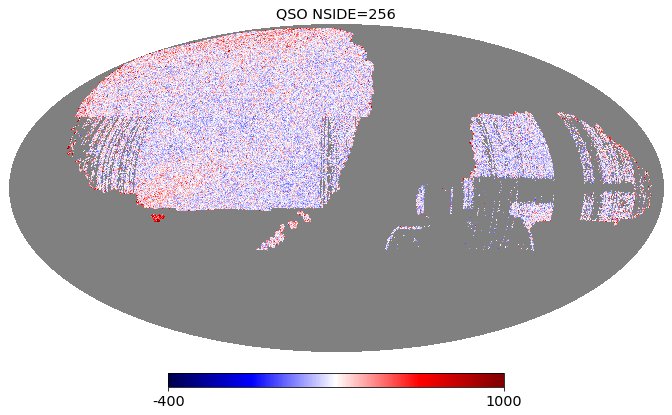

In [21]:
mask = ~np.in1d(maps_north['hp_idx'], maps_south['hp_idx'])
maps_combined = vstack([maps_north[mask], maps_south])
maps_combined.sort('hp_idx')

density = np.zeros(npix)  # density (per sq deg)
hp_mask = np.zeros(npix, dtype=bool)
density[maps_combined['hp_idx']] = maps_combined['density']
hp_mask[maps_combined['hp_idx']] = True
mplot = hp.ma(density)
mplot.mask = ~hp_mask

plt.figure(figsize=(9.7, 6))
hp.mollview(mplot, min=-400, max=1000, rot=(120, 0, 0), fig=1, xsize=8000, title='{} NSIDE={}'.format(target_class, nside))
plt.savefig('plots/{}_{}_tmp.png'.format(target_class, nside), dpi=600)
plt.show()

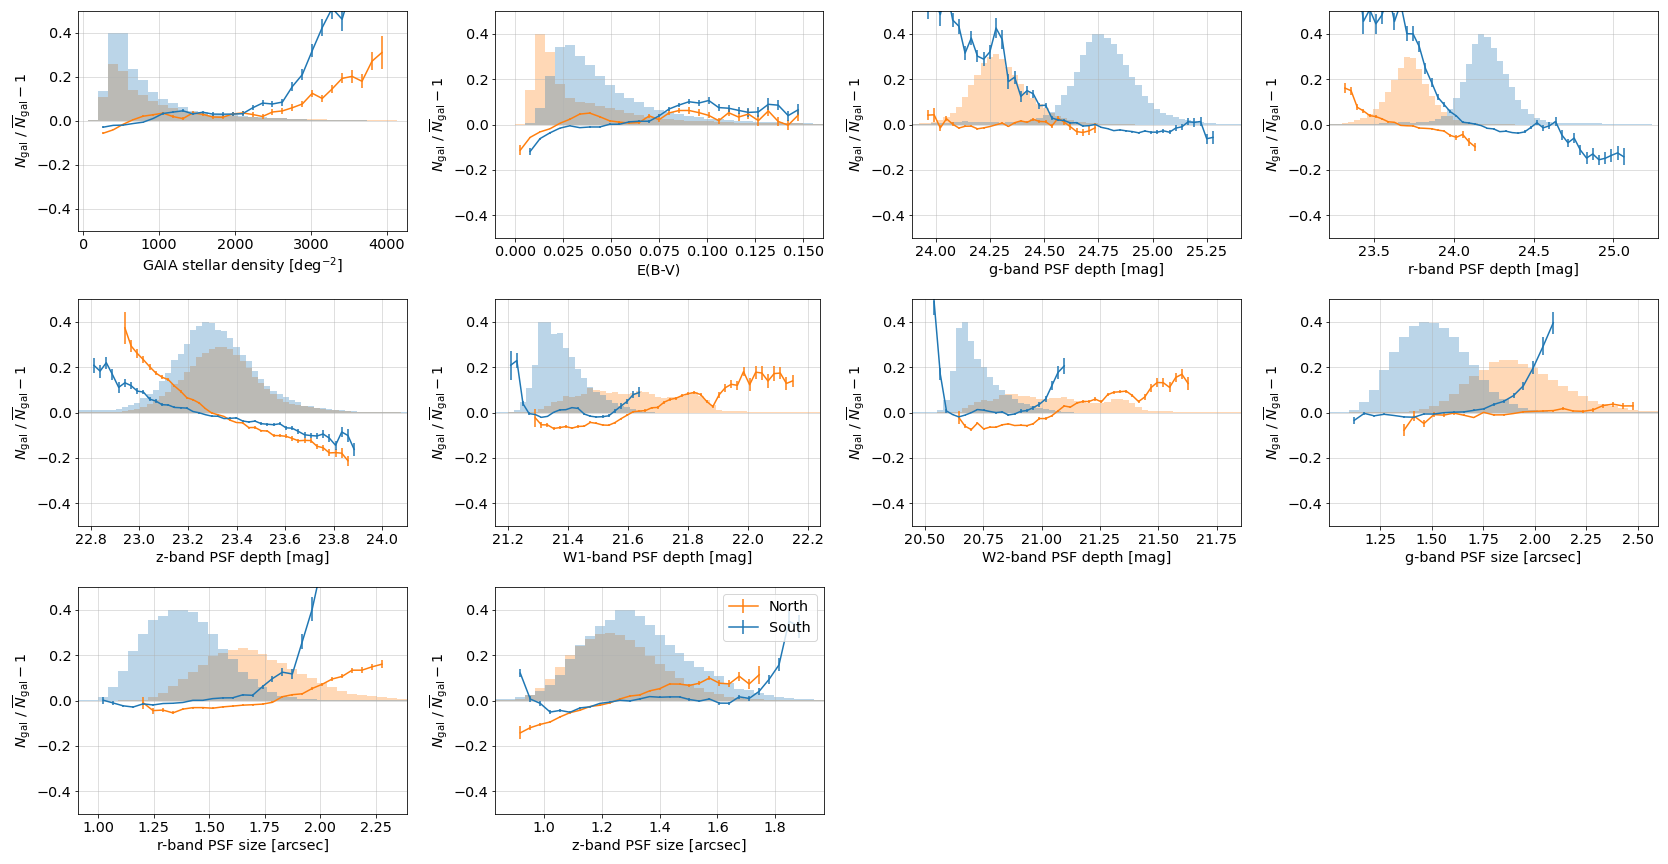

In [22]:
var_range = 0.5
minsize = 100

for index, xname in enumerate(xnames):
    
    bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])
        
    bin_width = bin_edges[1]-bin_edges[0]
    histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
    xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

    # normalize the histograms to the histogram of the full sample
    bincount_max = np.maximum(np.histogram(maps_north[xname], bins=histbin_edge)[0].max(), 
                              np.histogram(maps_south[xname], bins=histbin_edge)[0].max())

    fig, ax = plt.subplots(figsize=(5.8, 4))

    maps_mask = np.ones(len(maps_north), dtype=bool)
    mean_density = np.sum(maps_north['density']*maps_north['pix_frac'])/np.sum(maps_north['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_north[xname][maps_mask], maps_north['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_north['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_north[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='North', color='C1')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C1')

    maps_mask = np.ones(len(maps_south), dtype=bool)
    mean_density = np.sum(maps_south['density']*maps_south['pix_frac'])/np.sum(maps_south['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_south[xname][maps_mask], maps_south['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_south['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_south[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='South', color='C0')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C0')

    ax.grid(alpha=0.5)
    ax.set_xlabel(xlabels[index])
    ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
    ax.axis([xmin, xmax, -var_range, var_range])
    if index==len(xnames)-1:
        plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
    plt.close()

os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 4x plots/tmp_systematics_{}_{}.png'.format(target_class, len(xnames), target_class, nside))
Image(filename='plots/tmp_systematics_{}_{}.png'.format(target_class, nside))

__Use EBV-corrected depths__

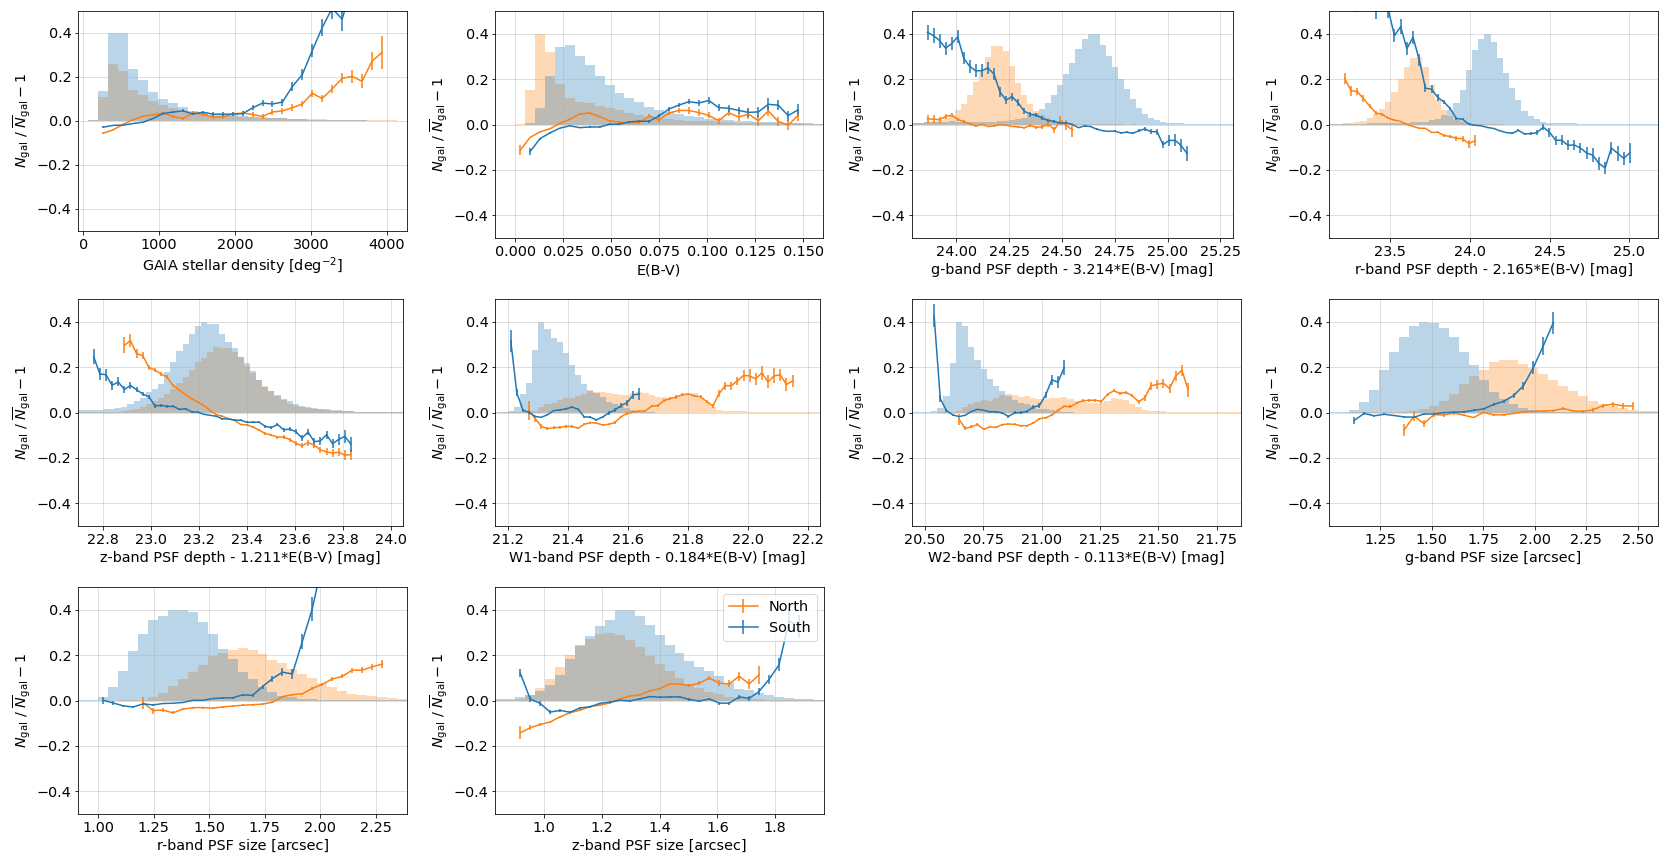

In [23]:
var_range = 0.5
minsize = 100

for index, xname in enumerate(xnames):
    
    if 'depth' in xname:
        xname += '_ebv'
    bin_edges = np.linspace(*bin_params[xname], bin_params[xname+'_nbins'])
        
    bin_width = bin_edges[1]-bin_edges[0]
    histbin_edge = np.arange(bin_edges[0] - 2*bin_width, bin_edges[-1] + 2.1*bin_width, bin_width)
    xmin, xmax = bin_edges[0] - 2*bin_width, bin_edges[-1] + 2*bin_width

    # normalize the histograms to the histogram of the full sample
    bincount_max = np.maximum(np.histogram(maps_north[xname], bins=histbin_edge)[0].max(), 
                              np.histogram(maps_south[xname], bins=histbin_edge)[0].max())

    fig, ax = plt.subplots(figsize=(5.8, 4))

    maps_mask = np.ones(len(maps_north), dtype=bool)
    mean_density = np.sum(maps_north['density']*maps_north['pix_frac'])/np.sum(maps_north['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_north[xname][maps_mask], maps_north['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_north['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_north[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='North', color='C1')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C1')

    maps_mask = np.ones(len(maps_south), dtype=bool)
    mean_density = np.sum(maps_south['density']*maps_south['pix_frac'])/np.sum(maps_south['pix_frac'])
    bin_center, _, bin_mean, bin_error = binned_mean(maps_south[xname][maps_mask], maps_south['density'][maps_mask]/mean_density, bin_edges=bin_edges, weights=maps_south['pix_frac'][maps_mask], minsize=minsize)
    histbin_center = (histbin_edge[1:]+histbin_edge[:-1])/2
    bincount, _ = np.histogram(maps_south[xname][maps_mask], bins=histbin_edge)
    bincount = 0.8*var_range*bincount/bincount_max
    ax.errorbar(bin_center, bin_mean-1, yerr=bin_error, label='South', color='C0')
    ax.hist(histbin_center, bins=histbin_edge, weights=bincount, alpha=0.3, color='C0')

    ax.grid(alpha=0.5)
    ax.set_xlabel(xlabels_ebv[index])
    ax.set_ylabel(r'$N_\mathrm{gal}\ /\ \overline{N}_\mathrm{gal} - 1$')
    ax.axis([xmin, xmax, -var_range, var_range])
    if index==len(xnames)-1:
        plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig('tmp/{}_{}.png'.format(target_class, index+1))
    plt.close()

os.system('montage tmp/{}_{{1..{}}}.png -geometry 100% -tile 4x plots/tmp_systematics_{}_{}_ebv_corr.png'.format(target_class, len(xnames), target_class, nside))
Image(filename='plots/tmp_systematics_{}_{}_ebv_corr.png'.format(target_class, nside))